# Fixed Evaluation: Full Precision@k + Fair Latency Breakdown

**Changes based on Ralph's feedback:**

1. **Precision@k** now reported at k ∈ {10, 50, 100, 1000} — not just @10
2. **Recall@k** now reported at k ∈ {10, 50, 100, 1000} — matched with Precision
3. **NDCG@k** now reported at k ∈ {10, 50, 100, 1000}
4. **Latency** broken into 3 components: encoding time + FAISS search time + network time
   so BGE (local GPU) and OpenAI (API) are compared fairly

## 1 · Imports & Load Saved Results

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import faiss
import torch
from dotenv import load_dotenv
from nltk.tokenize import word_tokenize
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

load_dotenv()
OPENAI_KEY = os.getenv('OPENAI_API_KEY')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Load all saved retrieval results ────────────────────────────────────────
production_df = pd.read_excel('dataset/production_results.xlsx')
bm25_df       = pd.read_csv('result/3_baseline_comparison/retrieval_bm25.csv')
minilm_df     = pd.read_csv('result/3_baseline_comparison/retrieval_minilm.csv')
bge_df        = pd.read_csv('result/3_baseline_comparison/retrieval_bge.csv')
openai_df     = pd.read_csv('result/3_baseline_comparison/retrieval_openai.csv')

all_companies = pd.read_csv('result/3_baseline_comparison/company_corpus.csv')
summaries     = all_companies['summary'].fillna('').tolist()

with open('dataset/goi_search_results.json', 'r') as f:
    data = json.load(f)

print(f'Queries          : {len(data)}')
print(f'Companies        : {len(all_companies):,}')
print(f'Production rows  : {len(production_df):,}')

/home/ma/ma_ma/ma_mpandya/Thesis/thesis/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Queries          : 101
Companies        : 98,716
Production rows  : 101,000


## 2 · Fixed Evaluation — Precision, Recall & NDCG at All k

**Ralph's feedback:** If you report Recall@1000 you must also report Precision@1000.
Report all metrics at k ∈ {10, 50, 100, 1000}.

**Pseudo-relevance labels:** A company is relevant if it appears in production top-100.

In [3]:
# ── Metric functions ────────────────────────────────────────────────────────
def get_relevant(query_id, top_k=100):
    return set(production_df[
        (production_df['query_id'] == query_id) &
        (production_df['rank'] <= top_k)
    ]['domain'].tolist())

def precision_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & relevant) / k if k else 0

def recall_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & relevant) / len(relevant) if relevant else 0

def dcg_at_k(retrieved, relevant, k):
    return sum(
        1 / np.log2(i + 2)
        for i, d in enumerate(retrieved[:k]) if d in relevant
    )

def ndcg_at_k(retrieved, relevant, k):
    ideal = dcg_at_k(list(relevant), relevant, k)
    return dcg_at_k(retrieved, relevant, k) / ideal if ideal else 0

# ── Evaluate all methods at all k ────────────────────────────────────────────
# Ralph: report Precision AND Recall at SAME k values
K_VALUES = [10, 50, 100, 1000]

method_dfs = {
    'BM25':   bm25_df,
    'MiniLM': minilm_df,
    'BGE':    bge_df,
    'OpenAI': openai_df,
}

all_rows = []
for item in data:
    qid      = item['query_id']
    query    = item['query']
    relevant = get_relevant(qid)

    for method, df in method_dfs.items():
        retrieved = (
            df[df['query_id'] == qid]
            .sort_values('rank')['domain']
            .tolist()
        )
        for k in K_VALUES:
            all_rows.append({
                'query_id' : qid,
                'query'    : query,
                'method'   : method,
                'k'        : k,
                'precision': precision_at_k(retrieved, relevant, k),
                'recall'   : recall_at_k(retrieved, relevant, k),
                'ndcg'     : ndcg_at_k(retrieved, relevant, k),
            })

eval_df = pd.DataFrame(all_rows)
eval_df.to_csv('result/3_baseline_comparison/evaluation_fixed.csv', index=False)
print(f'Saved {len(eval_df):,} evaluation rows')

Saved 1,616 evaluation rows


## 3 · Full Results Table

Averaged across all 101 queries. Precision and Recall always shown at the same k.

In [4]:
METHOD_ORDER = ['BM25', 'MiniLM', 'BGE', 'OpenAI']

print('=' * 80)
print(f'{'Method':<10} {'k':>6} | {'NDCG':>7} | {'Precision':>10} | {'Recall':>8}')
print('=' * 80)

summary_rows = []
for method in METHOD_ORDER:
    for k in K_VALUES:
        subset = eval_df[(eval_df['method'] == method) & (eval_df['k'] == k)]
        ndcg   = subset['ndcg'].mean()
        prec   = subset['precision'].mean()
        rec    = subset['recall'].mean()
        print(f'{method:<10} {k:>6} | {ndcg:>7.3f} | {prec:>10.3f} | {rec:>8.3f}')
        summary_rows.append({
            'Method': method, 'k': k,
            'NDCG': round(ndcg, 3),
            'Precision': round(prec, 3),
            'Recall': round(rec, 3),
        })
    print('-' * 80)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('result/summary_fixed.csv', index=False)
print('\nSaved to result/summary_fixed.csv')

Method          k |    NDCG |  Precision |   Recall
BM25           10 |   0.166 |      0.156 |    0.016
BM25           50 |   0.144 |      0.136 |    0.068
BM25          100 |   0.134 |      0.128 |    0.128
BM25         1000 |   0.446 |      0.068 |    0.682
--------------------------------------------------------------------------------
MiniLM         10 |   0.192 |      0.186 |    0.019
MiniLM         50 |   0.150 |      0.138 |    0.069
MiniLM        100 |   0.133 |      0.122 |    0.122
MiniLM       1000 |   0.432 |      0.065 |    0.653
--------------------------------------------------------------------------------
BGE            10 |   0.227 |      0.216 |    0.022
BGE            50 |   0.187 |      0.173 |    0.087
BGE           100 |   0.170 |      0.159 |    0.159
BGE          1000 |   0.527 |      0.080 |    0.796
--------------------------------------------------------------------------------
OpenAI         10 |   0.227 |      0.224 |    0.022
OpenAI         50 |   0.174 |

## 4 · Fair Latency Breakdown

**Ralph's feedback:** OpenAI latency includes network time which is not a model property.
We need to break latency into 3 components so methods are compared fairly:

| Component | BM25 | MiniLM | BGE | OpenAI |
|---|---|---|---|---|
| **Query encoding** | 0ms (tokenise) | Model forward pass | Model forward pass | API call time |
| **FAISS search** | N/A | Vector search | Vector search | Vector search |
| **Network time** | 0ms | 0ms | 0ms | HTTP round-trip to OpenAI |

BGE is purely local — no network. OpenAI's latency is partly network latency, not model speed.
We measure each component separately over 20 queries for stable estimates.

In [6]:
# ── Rebuild indices & models for latency measurement ────────────────────────
print('Rebuilding indices for latency measurement...')

# BM25
corpus_tokens = [word_tokenize(s.lower()) if isinstance(s, str) else [] for s in summaries]
bm25_index = BM25Okapi(corpus_tokens)

# MiniLM
model_minilm = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
emb_minilm   = np.load('result/3_baseline_comparison/embeddings_minilm.npy').astype('float32')
index_minilm = faiss.IndexFlatL2(emb_minilm.shape[1])
index_minilm.add(emb_minilm)

# BGE
model_bge  = SentenceTransformer('BAAI/bge-large-en-v1.5', device=DEVICE)
emb_bge    = np.load('result/3_baseline_comparison/embeddings_bge.npy').astype('float32')
index_bge  = faiss.IndexFlatIP(emb_bge.shape[1])
index_bge.add(emb_bge)

# OpenAI
client       = OpenAI(api_key=OPENAI_KEY)
emb_openai   = np.load('result/3_baseline_comparison/embeddings_openai.npy').astype('float32')
index_openai = faiss.IndexFlatIP(emb_openai.shape[1])
index_openai.add(emb_openai)

print('All indices ready!')

Rebuilding indices for latency measurement...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6085.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1973.85it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All indices ready!


In [7]:
# ── Measure each component separately ───────────────────────────────────────
BENCH_QUERIES = [item['query'] for item in data[:20]]  # 20 queries for stable estimate
N = len(BENCH_QUERIES)

latency = {m: {'encode_ms': 0, 'search_ms': 0, 'network_ms': 0} for m in METHOD_ORDER}

# ── BM25 ─────────────────────────────────────────────────────────────────────
encode_times, search_times = [], []
for q in BENCH_QUERIES:
    t0 = time.perf_counter()
    tokens = word_tokenize(q.lower())          # encoding = tokenisation
    latency['BM25']['encode_ms'] += (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    scores = bm25_index.get_scores(tokens)
    _ = np.argsort(scores)[::-1][:1000]        # search = score + sort
    latency['BM25']['search_ms'] += (time.perf_counter() - t0) * 1000

latency['BM25']['encode_ms'] /= N
latency['BM25']['search_ms'] /= N
latency['BM25']['network_ms'] = 0.0
print(f"BM25    encode={latency['BM25']['encode_ms']:.1f}ms  search={latency['BM25']['search_ms']:.1f}ms  network=0ms")

# ── MiniLM ───────────────────────────────────────────────────────────────────
for q in BENCH_QUERIES:
    t0 = time.perf_counter()
    q_emb = model_minilm.encode([q], convert_to_numpy=True).astype('float32')
    latency['MiniLM']['encode_ms'] += (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    index_minilm.search(q_emb, 1000)
    latency['MiniLM']['search_ms'] += (time.perf_counter() - t0) * 1000

latency['MiniLM']['encode_ms'] /= N
latency['MiniLM']['search_ms'] /= N
latency['MiniLM']['network_ms'] = 0.0
print(f"MiniLM  encode={latency['MiniLM']['encode_ms']:.1f}ms  search={latency['MiniLM']['search_ms']:.1f}ms  network=0ms")

# ── BGE ──────────────────────────────────────────────────────────────────────
for q in BENCH_QUERIES:
    t0 = time.perf_counter()
    q_emb = model_bge.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype('float32')
    latency['BGE']['encode_ms'] += (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    index_bge.search(q_emb, 1000)
    latency['BGE']['search_ms'] += (time.perf_counter() - t0) * 1000

latency['BGE']['encode_ms'] /= N
latency['BGE']['search_ms'] /= N
latency['BGE']['network_ms'] = 0.0
print(f"BGE     encode={latency['BGE']['encode_ms']:.1f}ms  search={latency['BGE']['search_ms']:.1f}ms  network=0ms")

# ── OpenAI ───────────────────────────────────────────────────────────────────
# For OpenAI we measure:
#   network_ms = full API round-trip (encode via HTTP)
#   search_ms  = local FAISS search (same as other models)
#   encode_ms  = 0 (encoding happens on OpenAI servers, not measurable locally)
for q in BENCH_QUERIES:
    t0 = time.perf_counter()
    resp  = client.embeddings.create(input=[q], model='text-embedding-3-small')
    q_emb = np.array([resp.data[0].embedding], dtype='float32')
    latency['OpenAI']['network_ms'] += (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    index_openai.search(q_emb, 1000)
    latency['OpenAI']['search_ms'] += (time.perf_counter() - t0) * 1000

latency['OpenAI']['network_ms'] /= N
latency['OpenAI']['search_ms']  /= N
latency['OpenAI']['encode_ms']   = 0.0  # done on OpenAI servers
print(f"OpenAI  encode=N/A(server-side)  search={latency['OpenAI']['search_ms']:.1f}ms  network={latency['OpenAI']['network_ms']:.1f}ms")

BM25    encode=0.1ms  search=122.3ms  network=0ms
MiniLM  encode=35.5ms  search=5.3ms  network=0ms
BGE     encode=466.4ms  search=13.3ms  network=0ms
OpenAI  encode=N/A(server-side)  search=19.9ms  network=368.9ms


## 5 · Latency Summary Table

This table gives Ralph the **fair, uniform comparison** he asked for.

- **Local encode:** time to encode one query on local hardware (GPU/CPU)
- **FAISS search:** time to search the vector index
- **Network:** HTTP round-trip to external API (OpenAI only)
- **Total (local):** encode + search — the latency Istari would experience with self-hosted models
- **Total (API):** network + search — the latency with OpenAI in production

In [8]:
rows = []
for method in METHOD_ORDER:
    l = latency[method]
    enc   = l['encode_ms']
    srch  = l['search_ms']
    net   = l['network_ms']
    total = enc + srch + net
    rows.append({
        'Method'          : method,
        'Local encode (ms)': f"{enc:.1f}" if enc > 0 else 'N/A (server)',
        'FAISS search (ms)': f"{srch:.1f}",
        'Network (ms)'    : f"{net:.1f}" if net > 0 else '0 (local)',
        'Total (ms)'      : f"{total:.1f}",
        'Self-hostable'   : 'Yes' if method != 'OpenAI' else 'No',
    })

latency_df = pd.DataFrame(rows)
print('=== FAIR LATENCY BREAKDOWN ===')
print(latency_df.to_string(index=False))
latency_df.to_csv('result/latency_breakdown.csv', index=False)
print('\nSaved to result/latency_breakdown.csv')

=== FAIR LATENCY BREAKDOWN ===
Method Local encode (ms) FAISS search (ms) Network (ms) Total (ms) Self-hostable
  BM25               0.1             122.3    0 (local)      122.4           Yes
MiniLM              35.5               5.3    0 (local)       40.7           Yes
   BGE             466.4              13.3    0 (local)      479.7           Yes
OpenAI      N/A (server)              19.9        368.9      388.7            No

Saved to result/latency_breakdown.csv


## 6 · Final Comparison Table — Quality + Fair Speed

The complete updated table for Ralph combining all fixed metrics.

In [9]:
final_rows = []
for method in METHOD_ORDER:
    l = latency[method]
    total_ms = l['encode_ms'] + l['search_ms'] + l['network_ms']
    row = {'Method': method, 'Total latency (ms)': f"{total_ms:.1f}"}

    for k in K_VALUES:
        subset = eval_df[(eval_df['method'] == method) & (eval_df['k'] == k)]
        row[f'NDCG@{k}']      = round(subset['ndcg'].mean(), 3)
        row[f'Precision@{k}'] = round(subset['precision'].mean(), 3)
        row[f'Recall@{k}']    = round(subset['recall'].mean(), 3)

    final_rows.append(row)

final_df = pd.DataFrame(final_rows).set_index('Method')

# Print in sections for readability
print('=== NDCG ===')
ndcg_cols = [f'NDCG@{k}' for k in K_VALUES]
print(final_df[ndcg_cols].to_string())

print('\n=== PRECISION ===')
prec_cols = [f'Precision@{k}' for k in K_VALUES]
print(final_df[prec_cols].to_string())

print('\n=== RECALL ===')
rec_cols = [f'Recall@{k}' for k in K_VALUES]
print(final_df[rec_cols].to_string())

print('\n=== LATENCY ===')
print(final_df[['Total latency (ms)']].to_string())

final_df.to_csv('result/final_comparison_fixed.csv')
print('\nAll saved to result/final_comparison_fixed.csv')

=== NDCG ===
        NDCG@10  NDCG@50  NDCG@100  NDCG@1000
Method                                       
BM25      0.166    0.144     0.134      0.446
MiniLM    0.192    0.150     0.133      0.432
BGE       0.227    0.187     0.170      0.527
OpenAI    0.227    0.174     0.161      0.526

=== PRECISION ===
        Precision@10  Precision@50  Precision@100  Precision@1000
Method                                                           
BM25           0.156         0.136          0.128           0.068
MiniLM         0.186         0.138          0.122           0.065
BGE            0.216         0.173          0.159           0.080
OpenAI         0.224         0.160          0.149           0.080

=== RECALL ===
        Recall@10  Recall@50  Recall@100  Recall@1000
Method                                               
BM25        0.016      0.068       0.128        0.682
MiniLM      0.019      0.069       0.122        0.653
BGE         0.022      0.087       0.159        0.796
OpenAI    

## 7 · Updated Plots

Four panels: NDCG@k, Precision@k, Recall@k, and the fair latency breakdown.

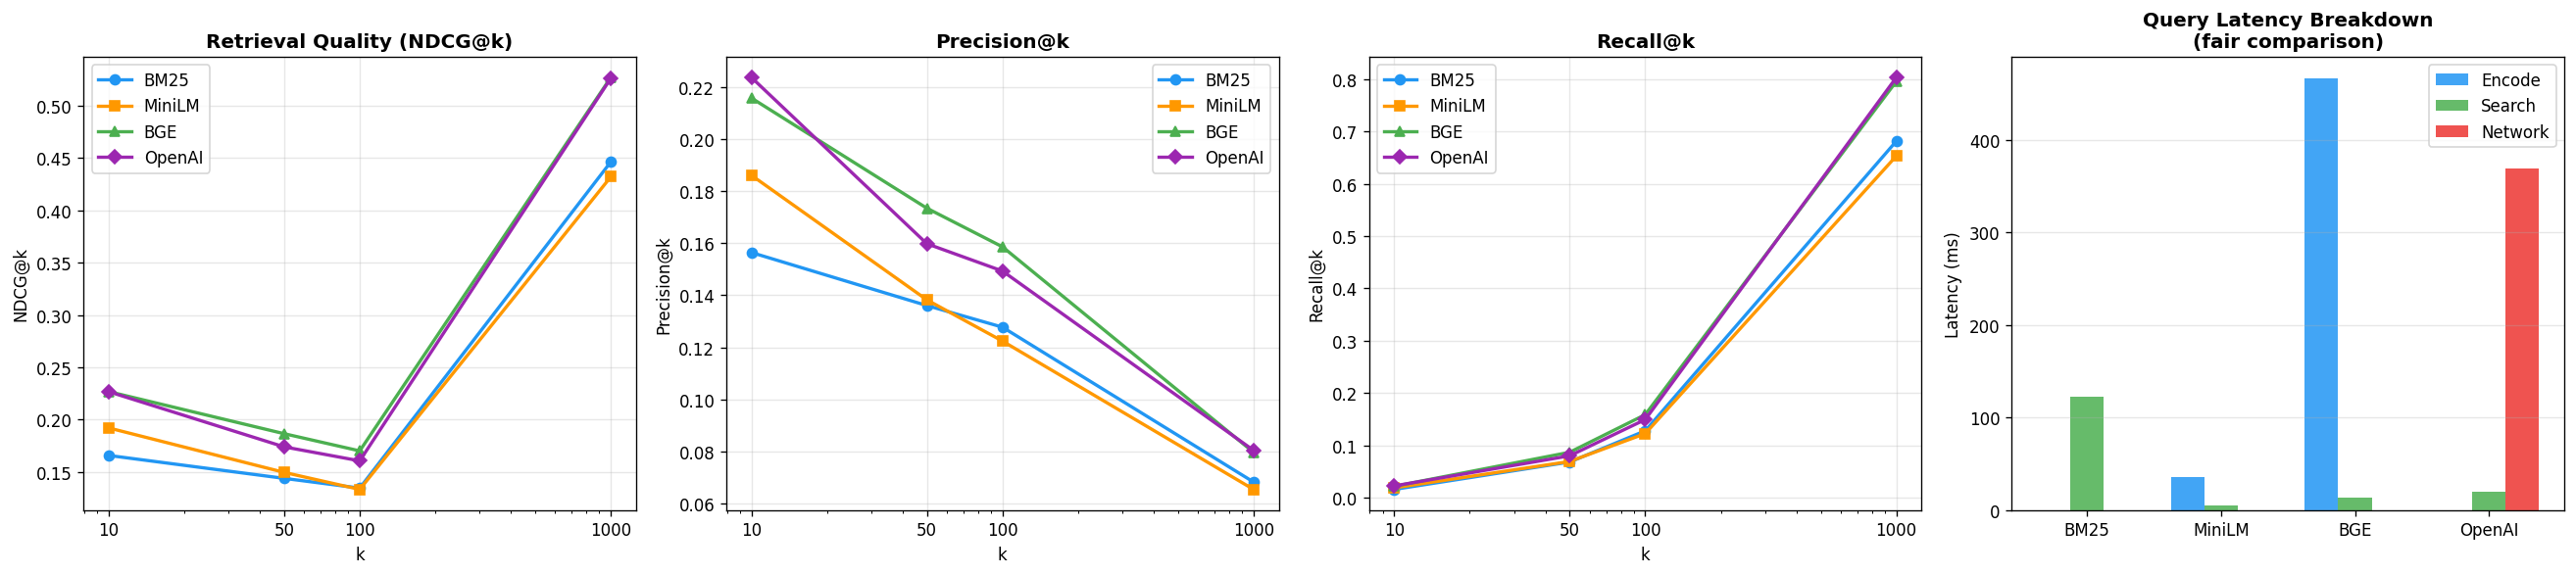

Saved to result/comparison_fixed.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

colors  = {'BM25':'#2196F3', 'MiniLM':'#FF9800', 'BGE':'#4CAF50', 'OpenAI':'#9C27B0'}
markers = {'BM25':'o',       'MiniLM':'s',        'BGE':'^',       'OpenAI':'D'}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# ── NDCG ─────────────────────────────────────────────────────────────────────
ax = axes[0]
for m in METHOD_ORDER:
    vals = [eval_df[(eval_df['method']==m)&(eval_df['k']==k)]['ndcg'].mean() for k in K_VALUES]
    ax.plot(K_VALUES, vals, marker=markers[m], color=colors[m], label=m, linewidth=2, markersize=6)
ax.set_xscale('log'); ax.set_xticks(K_VALUES); ax.set_xticklabels(K_VALUES)
ax.set_xlabel('k'); ax.set_ylabel('NDCG@k')
ax.set_title('Retrieval Quality (NDCG@k)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# ── PRECISION ────────────────────────────────────────────────────────────────
ax = axes[1]
for m in METHOD_ORDER:
    vals = [eval_df[(eval_df['method']==m)&(eval_df['k']==k)]['precision'].mean() for k in K_VALUES]
    ax.plot(K_VALUES, vals, marker=markers[m], color=colors[m], label=m, linewidth=2, markersize=6)
ax.set_xscale('log'); ax.set_xticks(K_VALUES); ax.set_xticklabels(K_VALUES)
ax.set_xlabel('k'); ax.set_ylabel('Precision@k')
ax.set_title('Precision@k', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# ── RECALL ───────────────────────────────────────────────────────────────────
ax = axes[2]
for m in METHOD_ORDER:
    vals = [eval_df[(eval_df['method']==m)&(eval_df['k']==k)]['recall'].mean() for k in K_VALUES]
    ax.plot(K_VALUES, vals, marker=markers[m], color=colors[m], label=m, linewidth=2, markersize=6)
ax.set_xscale('log'); ax.set_xticks(K_VALUES); ax.set_xticklabels(K_VALUES)
ax.set_xlabel('k'); ax.set_ylabel('Recall@k')
ax.set_title('Recall@k', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# ── LATENCY BREAKDOWN ────────────────────────────────────────────────────────
ax = axes[3]
x      = np.arange(len(METHOD_ORDER))
width  = 0.25
enc    = [latency[m]['encode_ms']  for m in METHOD_ORDER]
srch   = [latency[m]['search_ms']  for m in METHOD_ORDER]
net    = [latency[m]['network_ms'] for m in METHOD_ORDER]

b1 = ax.bar(x - width, enc,  width, label='Encode',  color='#42A5F5')
b2 = ax.bar(x,          srch, width, label='Search',  color='#66BB6A')
b3 = ax.bar(x + width, net,  width, label='Network', color='#EF5350')

ax.set_xticks(x); ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel('Latency (ms)')
ax.set_title('Query Latency Breakdown\n(fair comparison)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('result/comparison_fixed.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved to result/comparison_fixed.png')